In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import parscan_utils as pu
import parscan_plots as pp
for m in (co, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

In [2]:
import baseline_r0_setups as brs
import parscan_utils as pu
import parscan_utils_extended as pue
import cariaco_obs as co

# obs side
_, _, _, monthly_df, forcing = co.load_cariaco_targets(regime='upwelling',
                                                       months='hplc', agg='median',
                                                       include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

# model side — single point at default forcing
out = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                          scan_params={}, fixed_overrides=forcing)
print(out)  # full output, should have Growth__uptake_value + DetritusSink__sinking_value

<xarray.Dataset> Size: 146MB
Dimensions:                                 (time: 5000, phyto: 40, zoo: 40,
                                             full: 80, clock: 2)
Coordinates:
  * time                                    (time) float64 40kB 0.0 ... 4.999...
  * phyto                                   (phyto) float64 320B 0.2 ... 200.0
  * zoo                                     (zoo) float64 320B 2.0 ... 2e+03
  * clock                                   (clock) float64 16B 0.0 1.0
Dimensions without coordinates: full
Data variables: (12/104)
    Core__solver_kwargs                     <U49 196B '{"method": "RK45", "at...
    Core__solver_type                       <U9 36B 'solve_ivp'
    DetritusRemin__detritus                 <U1 4B 'D'
    DetritusRemin__k_remin                  float64 8B 0.1
    DetritusRemin__nutrient                 <U1 4B 'N'
    DetritusRemin__remineralization_value   (time) float64 40kB 0.0002363 ......
    ...                                      ...
 

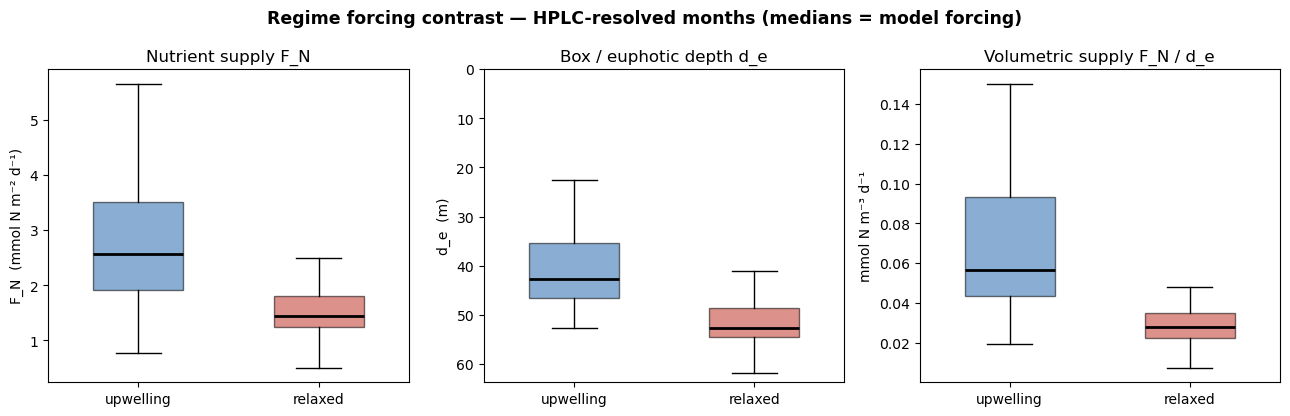

upwelling   n=31   F_N= 2.58   d_e= 42.8   T= 23.0°C   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   T= 25.4°C   F_N/d_e=0.0275


In [3]:
# ── Cell 4 — regime forcing (upwelling vs relaxed, HPLC months, +temperature) ─
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"T={f.get('Temperature__value', float('nan')):5.1f}°C   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_oldssm_approx_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 26 points using 8 workers...
1D Scan complete. Time taken: 15.90509 seconds.

=== OLD ssm approx on 40/0.2 grid (existing components) — F_N sweep ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   0.91   0.190   0.036   0.000   0.226  0.0000  0.0000   0.135   0.130   0.091   0.030   0.453
 1.000   1.08   0.274   0.084   0.000   0.358  0.0029  0.0000   0.191   0.235   0.181   0.059   0.906
 1.450   1.17   0.324   0.118   0.000   0.442  0.0167  0.0000   0.225   0.339   0.264   0.086   1.319
 1.500   1.18   0.327   0.123   0.000   0.450  0.0184  0.0000   0.228   0.352   0.273   0.089   1.365
 2.000   1.27   0.365   0.161 

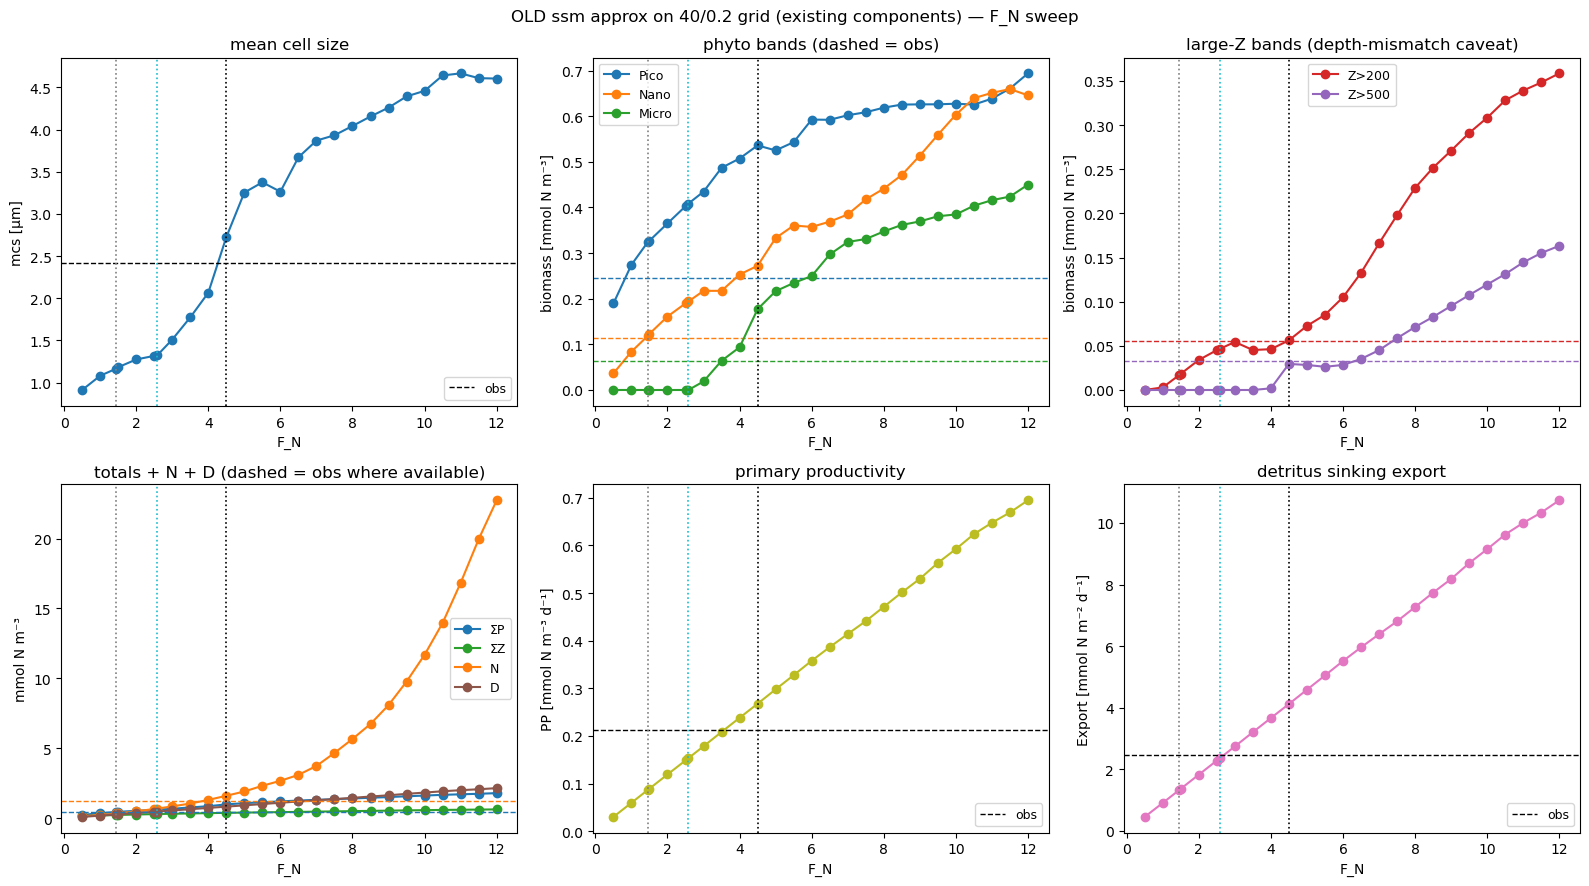

In [4]:
# F_N sweep — OLD cariaco_ssm model approximated on the 40/0.2 grid (existing components).
# setup_oldssm_approx_slim bakes d_e=50, T=20, fish on, Marañón μ + old K_s/I_max/K_sZ/σ.
# Fresh run; one parscan in this cell.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import cariaco_obs as co
import parscan_utils_extended as pue

obs_vec, labels, bin_defs, monthly_df, _ = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 12.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_banas',
    model_setup_name='setup_oldssm_approx_slim',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': 50.0})
header = "OLD ssm approx on 40/0.2 grid (existing components) — F_N sweep"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()

In [8]:
# ── Cell — Herbivory variant test ───────────────────────────────────────────
import importlib
importlib.reload(brs)   # pick up new herbivory model + setups
importlib.reload(pue)   # pick up new single-point helpers

# (1) Herbivory at DEFAULT parameters
for r in regimes:
    out = pu.run_single_point(brs.model_baseline_herb, brs.setup_baseline_herb,
                               scan_params={},
                               fixed_overrides=targets[r]['forcing'])
    m_herb = pue.extract_single_point_metrics(out, targets[r]['forcing'])
    obs    = pue.build_obs_refs(targets[r]['monthly_df'])
    header = (f"HERB at defaults — {r.upper()}  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    pue.print_single_point_comparison({'herb': m_herb}, obs, header)

# (2) Herbivory at OLD-MODEL parameter values
OLD_PARAMS = {
    'Grazing__KsZ':            0.487,
    'GrazingRouter__gge':      0.174,
    'DetritusRemin__k_remin':  0.076,
}
for r in regimes:
    overrides = {**targets[r]['forcing'], **OLD_PARAMS}
    out = pu.run_single_point(brs.model_baseline_herb, brs.setup_baseline_herb,
                               scan_params={}, fixed_overrides=overrides)
    m_herb = pue.extract_single_point_metrics(out, targets[r]['forcing'])
    obs    = pue.build_obs_refs(targets[r]['monthly_df'])
    header = (f"HERB at OLD param values — {r.upper()}  "
              f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[r]['forcing']['Inflow__de']:.1f})")
    pue.print_single_point_comparison({'herb+old': m_herb}, obs, header)


=== HERB at defaults — UPWELLING  (F_N=2.58, d_e=42.8) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
      herb  10.97   0.158   0.207   0.324   0.689  0.0215  0.0056   0.344   0.110   0.465   0.130   2.326
       obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192

=== HERB at defaults — RELAXED  (F_N=1.45, d_e=52.7) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
      herb   6.39   0.129   0.168   0.132   0.428  0.0044  0.0000   0.204   0.054   0.268   0.066   1.341
       obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654       -   0.181   1.398

=== HERB at OLD param values — UPWELLING  (F_N=2.58, d_e=42.8) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
  herb+old   4.04   0.373   0.466   0.176   1.015  0.0010  0.0000   0.23

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_slim' from 'cariaco_ssm_setup' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_ssm_setup' over 26 points using 8 workers...
1D Scan complete. Time taken: 9.65798 seconds.

=== OLD cariaco_ssm (as fitted, d_e=50, fish ON) — F_N sweep ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   1.13   0.137   0.046   0.000   0.184  0.0000  0.0000   0.145   0.154   0.089   0.029   0.446
 1.000   1.20   0.221   0.082   0.002   0.305  0.0024  0.0000   0.199   0.267   0.180   0.059   0.898
 1.450   1.27   0.269   0.109   0.003   0.381  0.0066  0.0000   0.235   0.386   0.262   0.086   1.308
 1.500   1.27   0.273   0.112   0.003   0.389  0.0065  0.0000   0.239   0.402   0.271   0.088   1.353
 2.000   1.28   0.324   0.126   0.007   0.458  0.0158  0.0000  

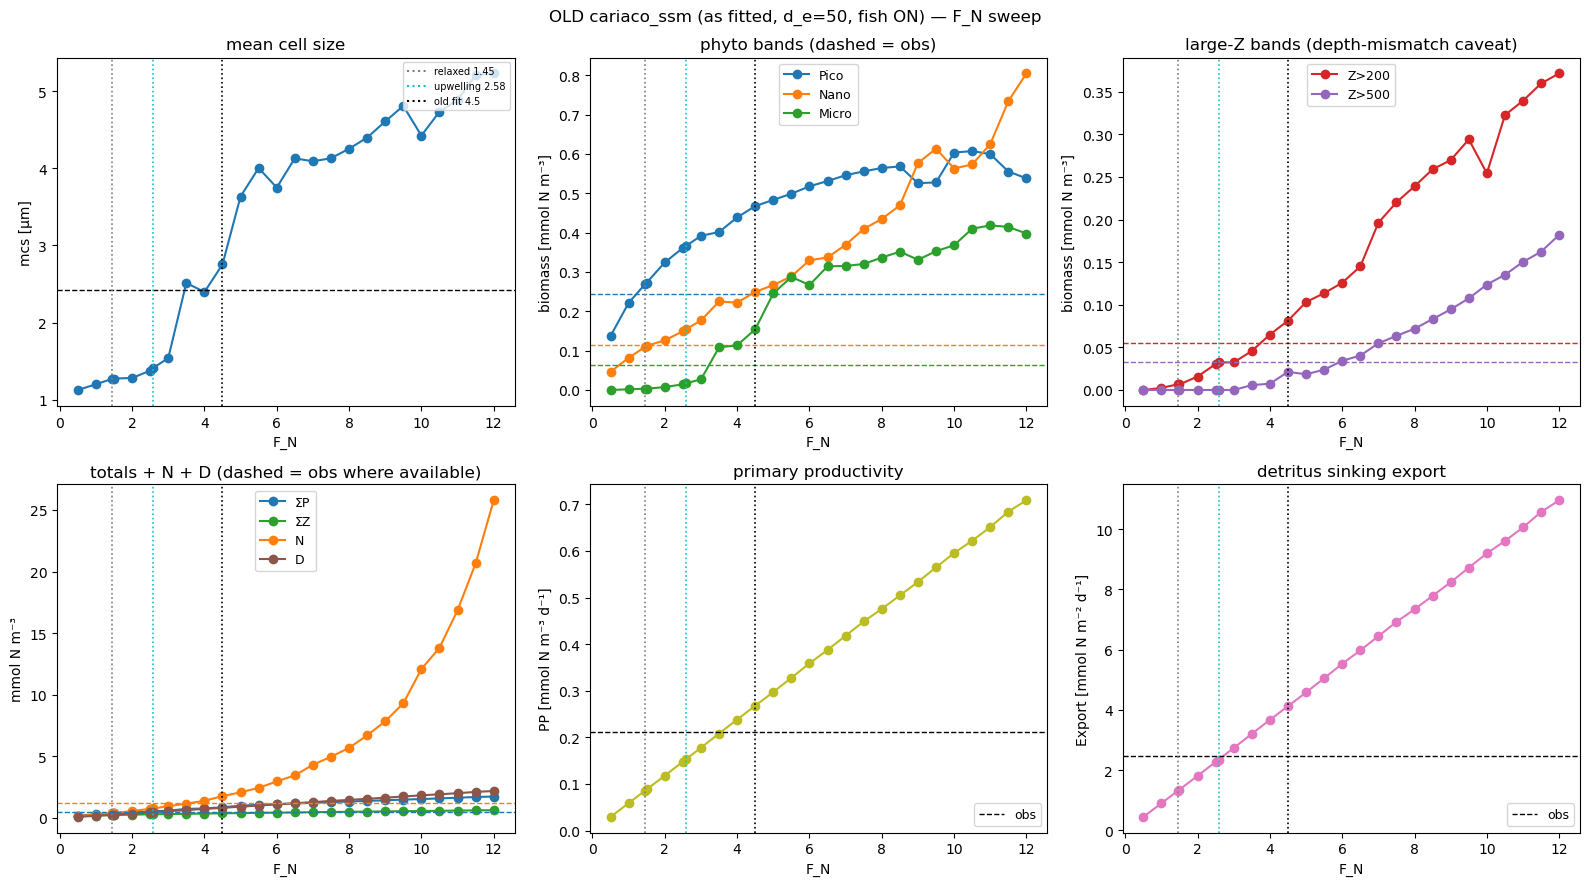

In [5]:
# =====================================================================
# F_N SWEEP — OLD MS3 model (cariaco_ssm), AS FITTED (Scan5 baseline).
# d_e pinned to 50; fish left ON (old module defaults); old comps/setups.
# Q1: is mcs(F_N) coherent (rising) or descending like the new baseline?
# Q2: what does it give at regime-median F_N vs the near-doubled 4.5 fit?
# Fresh run; one parscan in this cell.
# =====================================================================
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import cariaco_obs as co
import parscan_utils_extended as pue

# obs reference: pooled 'all' regime, same hplc-median yardstick as the new model
obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

# OLD fitted-model scalars (from run_2d_stabilityscan-Scan5_restart.py).
# d_e fixed at 50; FN is the scan axis; fish untouched (rate 0.005, biomass 1 -> ON).
ssm_fit_overrides = {
    'Inflow__de':               50.0,
    'GGE__gge':                 0.17416,   # Scan 1
    'GGE__f_egest_D':           0.55602,   # Scan 2
    'DetritusRemin__k_remin':   0.07590,   # Scan 2
    'PhytoMortality__f_mort_D': 0.47651,   # Scan 4
    'Grazing__KsZ':             0.487,     # FN x KsZ 2D best fit
}

# F_N grid 0.5-12, plus exact rows at relaxed/upwelling medians and the old fit
FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 12.0, 24),
                                      [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=ssm_fit_overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)

metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': 50.0})
header  = "OLD cariaco_ssm (as fitted, d_e=50, fish ON) — F_N sweep"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')

fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
# vertical guides: relaxed / upwelling regime-median F_N + the old fit F_N
marks = [(1.45, 'relaxed 1.45', 'C7'),
         (2.58, 'upwelling 2.58', 'C9'),
         (4.5,  'old fit 4.5', 'k')]
for ax in fig.axes:
    for fn, _, c in marks:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
proxies = [plt.Line2D([0], [0], color=c, ls=':') for _, _, c in marks]
fig.axes[0].legend(proxies, [lab for _, lab, _ in marks], fontsize=7, loc='upper right')
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_slim' from 'cariaco_ssm_setup' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_ssm_setup' over 57 points using 8 workers...
1D Scan complete. Time taken: 44.58171 seconds.

=== OLD ssm + TANIGUCHI growth (else old, fish ON, d_e=50) — F_N sweep ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   0.63   0.107   0.000   0.000   0.107  0.0000  0.0000   0.103   0.072   0.094   0.032   0.472
 0.906   0.63   0.143   0.000   0.000   0.143  0.0000  0.0000   0.147   0.103   0.170   0.057   0.850
 1.311   0.66   0.170   0.004   0.000   0.173  0.0000  0.0000   0.181   0.131   0.246   0.082   1.228
 1.450   0.66   0.177   0.004   0.000   0.181  0.0000  0.0000   0.192   0.142   0.271   0.090   1.356
 1.717   0.67   0.191   0.005   0.000   0.196  0.000

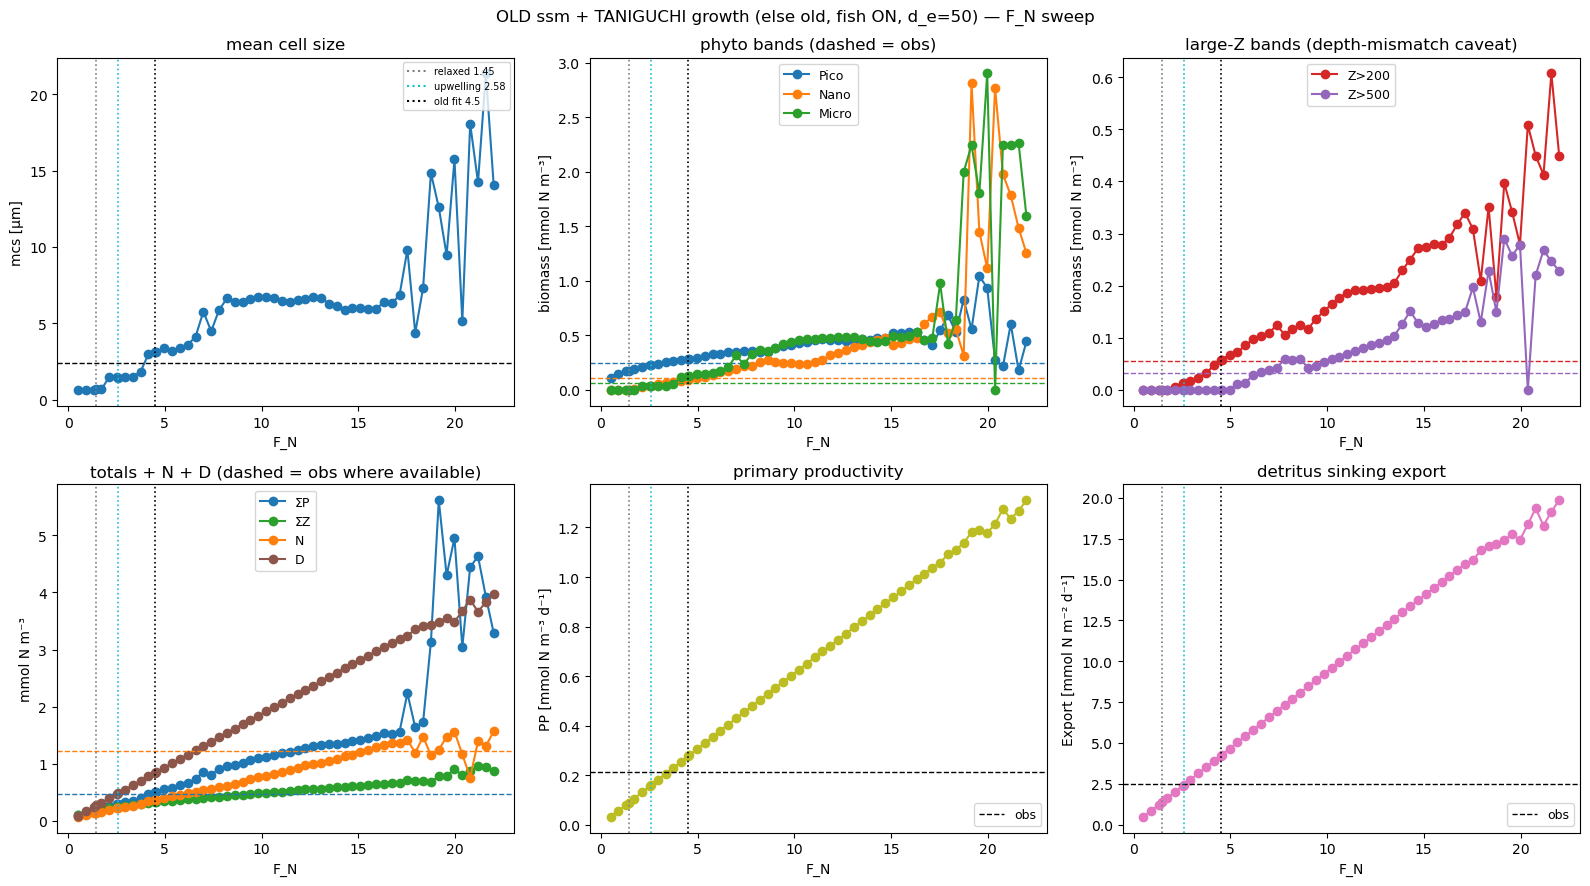

In [12]:
# =====================================================================
# STEP-BY-STEP DIFFERENCE TEST 1 — growth allometry, on the OLD model.
# OLD cariaco_ssm as fitted, EXCEPT growth Marañón -> Taniguchi
# (μ_max + K_s together), with mortality coupled (m_P = 0.1·μ_max,Tani).
# Everything else old: 0.5 µm / 12 classes, σ=0.25 kernel, old I_max,
# fish ON, Scan5 fit scalars, d_e=50.  Fresh run; one parscan in this cell.
# Q: does swapping growth ALONE flip mcs(F_N) from rising to descending?
# =====================================================================
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import cariaco_obs as co
import parscan_utils_extended as pue
from cariaco_ssm_setup import phyto_esd as ssm_phyto_esd   # OLD 12-class, 0.5 µm grid

# obs reference: pooled 'all' regime (same yardstick as the Marañón sweep)
obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

# Taniguchi growth on the OLD grid + coupled Banas-form mortality
mu_tani = 1.36 * ssm_phyto_esd ** (-0.16)      # d⁻¹
ks_tani = 0.33 * ssm_phyto_esd ** ( 0.48)      # mmol N m⁻³
mP_tani = 0.1 * mu_tani                        # Banas form, now tracks Taniguchi μ

# old fitted scalars + the growth swap (the ONLY change vs the Marañón sweep)
overrides = {
    'Inflow__de':               50.0,
    'GGE__gge':                 0.17416,
    'GGE__f_egest_D':           0.55602,
    'DetritusRemin__k_remin':   0.07590,
    'PhytoMortality__f_mort_D': 0.47651,
    'Grazing__KsZ':             0.487,
    'Growth__mu_max':           mu_tani,        # <- Marañón -> Taniguchi
    'Growth__halfsat':          ks_tani,        # <-
    'PhytoMortality__rate':     mP_tani,        # <- coupled mortality
}

FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 22.0, 54),
                                      [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)

metrics_tani = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': 50.0})
header = "OLD ssm + TANIGUCHI growth (else old, fish ON, d_e=50) — F_N sweep"
pue.print_scan_table_1d(metrics_tani, obs_refs, header, axis_label='F_N')

fig = pue.plot_scan_panels_1d(metrics_tani, obs_refs, header, axis_label='F_N')
marks = [(1.45, 'relaxed 1.45', 'C7'),
         (2.58, 'upwelling 2.58', 'C9'),
         (4.5,  'old fit 4.5', 'k')]
for ax in fig.axes:
    for fn, _, c in marks:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
proxies = [plt.Line2D([0], [0], color=c, ls=':') for _, _, c in marks]
fig.axes[0].legend(proxies, [lab for _, lab, _ in marks], fontsize=7, loc='upper right')
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_slim_f02_n40' from 'cariaco_ssm_setup' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_ssm_setup' over 27 points using 8 workers...
1D Scan complete. Time taken: 26.53176 seconds.

=== OLD ssm — model_setup_slim_f02_n40, taniguchi growth (fish ON) — F_N sweep ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   0.63   0.096   0.000   0.000   0.096  0.0000  0.0000   0.094   0.044   0.095   0.033   0.477
 1.261   0.63   0.153   0.000   0.000   0.153  0.0000  0.0000   0.171   0.077   0.237   0.079   1.187
 1.450   0.63   0.163   0.000   0.000   0.163  0.0000  0.0000   0.184   0.086   0.273   0.091   1.364
 2.022   0.65   0.189   0.003   0.000   0.192  0.0000  0.0000   0.217   0.115   0.380   0.125   1.902
 2.580   0.76   0.216   0.019   0.00

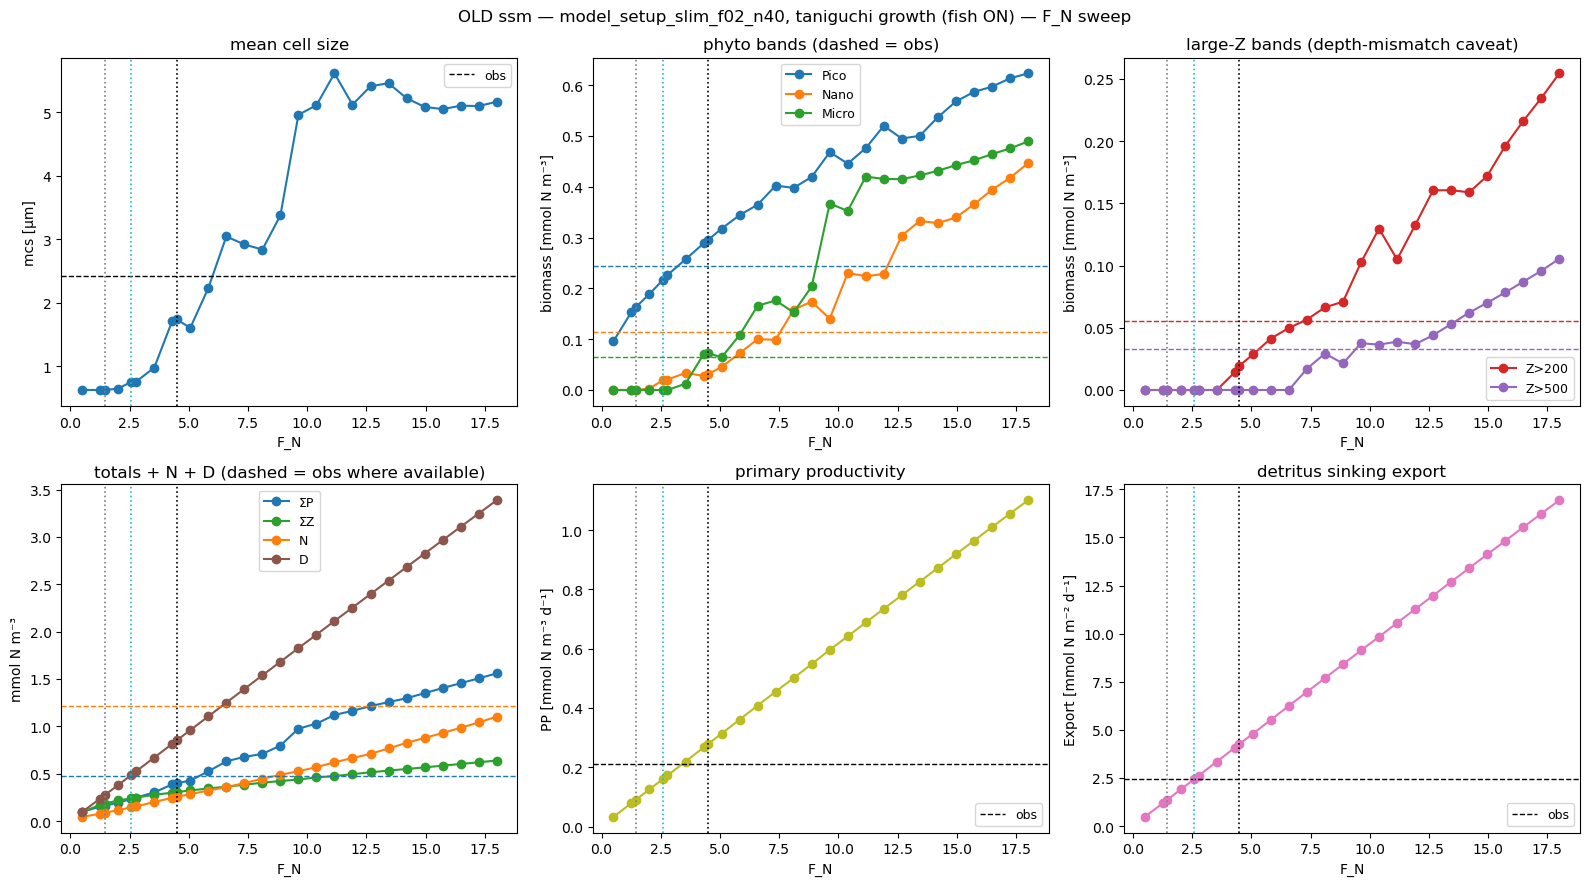

In [9]:
# FLOOR × RESOLUTION difference-test runner — set the 3 knobs, run, repeat.
# Uses the grid variants added to cariaco_ssm_setup.py. One parscan per run.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import cariaco_obs as co
import parscan_utils_extended as pue
import cariaco_ssm_setup as ssm

# ---- KNOBS ---------------------------------------------------------------
SETUP_NAME = 'model_setup_slim_f02_n40'   # which floor/resolution variant
GRID_ESD   = ssm.phyto_esd_f02_n40        # the grid array MATCHING SETUP_NAME
GROWTH     = 'taniguchi'                     # 'maranon' (default) or 'taniguchi'
# --------------------------------------------------------------------------

obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

overrides = {
    'Inflow__de':               50.0,
    'GGE__gge':                 0.17416,
    'GGE__f_egest_D':           0.55602,
    'DetritusRemin__k_remin':   0.07590,
    'PhytoMortality__f_mort_D': 0.47651,
    'Grazing__KsZ':             0.487,
}
if GROWTH == 'taniguchi':
    mu_tani = 1.36 * GRID_ESD ** (-0.16)
    overrides['Growth__mu_max']       = mu_tani
    overrides['Growth__halfsat']      = 0.33 * GRID_ESD ** (0.48)
    overrides['PhytoMortality__rate'] = 0.1 * mu_tani

FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 18.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name=SETUP_NAME,
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': 50.0})
header = f"OLD ssm — {SETUP_NAME}, {GROWTH} growth (fish ON) — F_N sweep"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_slim_f02_n40' from 'cariaco_ssm_setup' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_ssm_setup' over 27 points using 8 workers...
1D Scan complete. Time taken: 33.43248 seconds.

=== OLD ssm f02_n40 — maranon growth × uniform mortality (else old, fish ON) — F_N sweep ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   1.08   0.152   0.047   0.000   0.199  0.0000  0.0000   0.118   0.161   0.093   0.032   0.464
 1.450   1.14   0.295   0.102   0.000   0.396  0.0118  0.0000   0.213   0.429   0.267   0.091   1.334
 1.870   1.32   0.332   0.156   0.000   0.488  0.0270  0.0000   0.229   0.528   0.347   0.117   1.733
 2.580   1.23   0.409   0.166   0.000   0.575  0.0341  0.0000   0.276   0.823   0.477   0.160   2.383
 3.239   1.33   0.440   0.

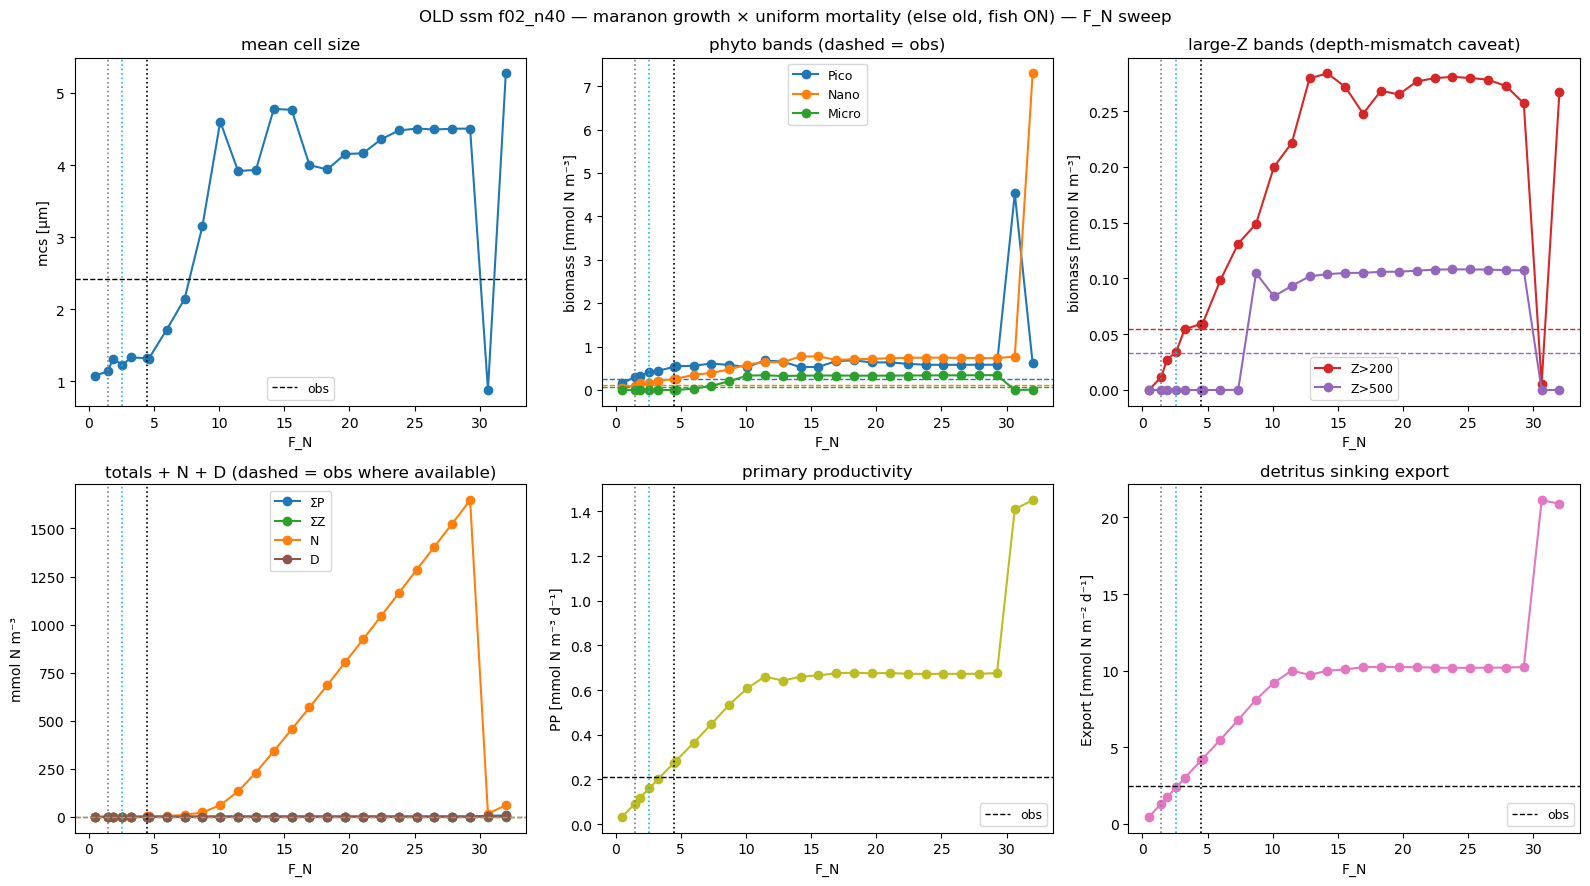

In [27]:
# 2×2 — GROWTH × MORTALITY on f02_n40 (else old, fish ON). Set 2 knobs, run, repeat.
# Pulls apart whether the descending mcs limb needs Taniguchi growth, uniform
# mortality, or BOTH. One parscan per run; everything else identical across the four.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import cariaco_obs as co
import parscan_utils_extended as pue
import cariaco_ssm_setup as ssm

# ---- KNOBS ---------------------------------------------------------------
GROWTH = 'maranon'   # 'maranon' (module default) or 'taniguchi'
MORT   = 'uniform'     # 'banas' (0.1·μ of the active growth) or 'uniform' (0.02)
# --------------------------------------------------------------------------
GRID_ESD = ssm.phyto_esd_f02_n40          # 0.2 µm, 40-class grid

obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

overrides = {
    'Inflow__de':               50.0,
    'GGE__gge':                 0.17416,
    'GGE__f_egest_D':           0.55602,
    'DetritusRemin__k_remin':   0.07590,
    'PhytoMortality__f_mort_D': 0.47651,
    'Grazing__KsZ':             0.487,
}

# growth: Marañón = module default (no override); Taniguchi = override μ_max + K_s
if GROWTH == 'taniguchi':
    mu = 1.36 * GRID_ESD ** (-0.16)
    overrides['Growth__mu_max']  = mu
    overrides['Growth__halfsat'] = 0.33 * GRID_ESD ** (0.48)
else:  # maranon (module default growth)
    mu = ssm.compute_mu_max_maranon(GRID_ESD)

# mortality FORM: Banas = 0.1·μ of the ACTIVE growth; uniform = 0.02 flat
if MORT == 'banas':
    overrides['PhytoMortality__rate'] = 0.001 * mu
else:  # uniform
    overrides['PhytoMortality__rate'] = np.full(len(GRID_ESD), 0.1)

FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 32.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_slim_f02_n40',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': 50.0})
header = f"OLD ssm f02_n40 — {GROWTH} growth × {MORT} mortality (else old, fish ON) — F_N sweep"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_phytoquad_pc' and setup 'model_setup_slim_phytoquad_pc' from 'cariaco_ssm_setup' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_ssm_setup' over 26 points using 8 workers...
1D Scan complete. Time taken: 13.37482 seconds.

=== OLD ssm f02_n40 — maranon, perclass QUAD m_P=2.1 (else old, fish ON) — F_N sweep ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   1.94   0.193   0.082   0.035   0.310  0.0022  0.0000   0.136   0.090   0.090   0.030   0.451
 1.000   1.94   0.256   0.117   0.043   0.416  0.0150  0.0000   0.188   0.181   0.182   0.060   0.908
 1.450   1.93   0.300   0.144   0.047   0.491  0.0247  0.0000   0.222   0.275   0.264   0.087   1.321
 1.500   1.93   0.304   0.147   0.048   0.499  0.0257  0.0000   0.225   0.287   0.273   0.090   1.367
 2.000   1.9

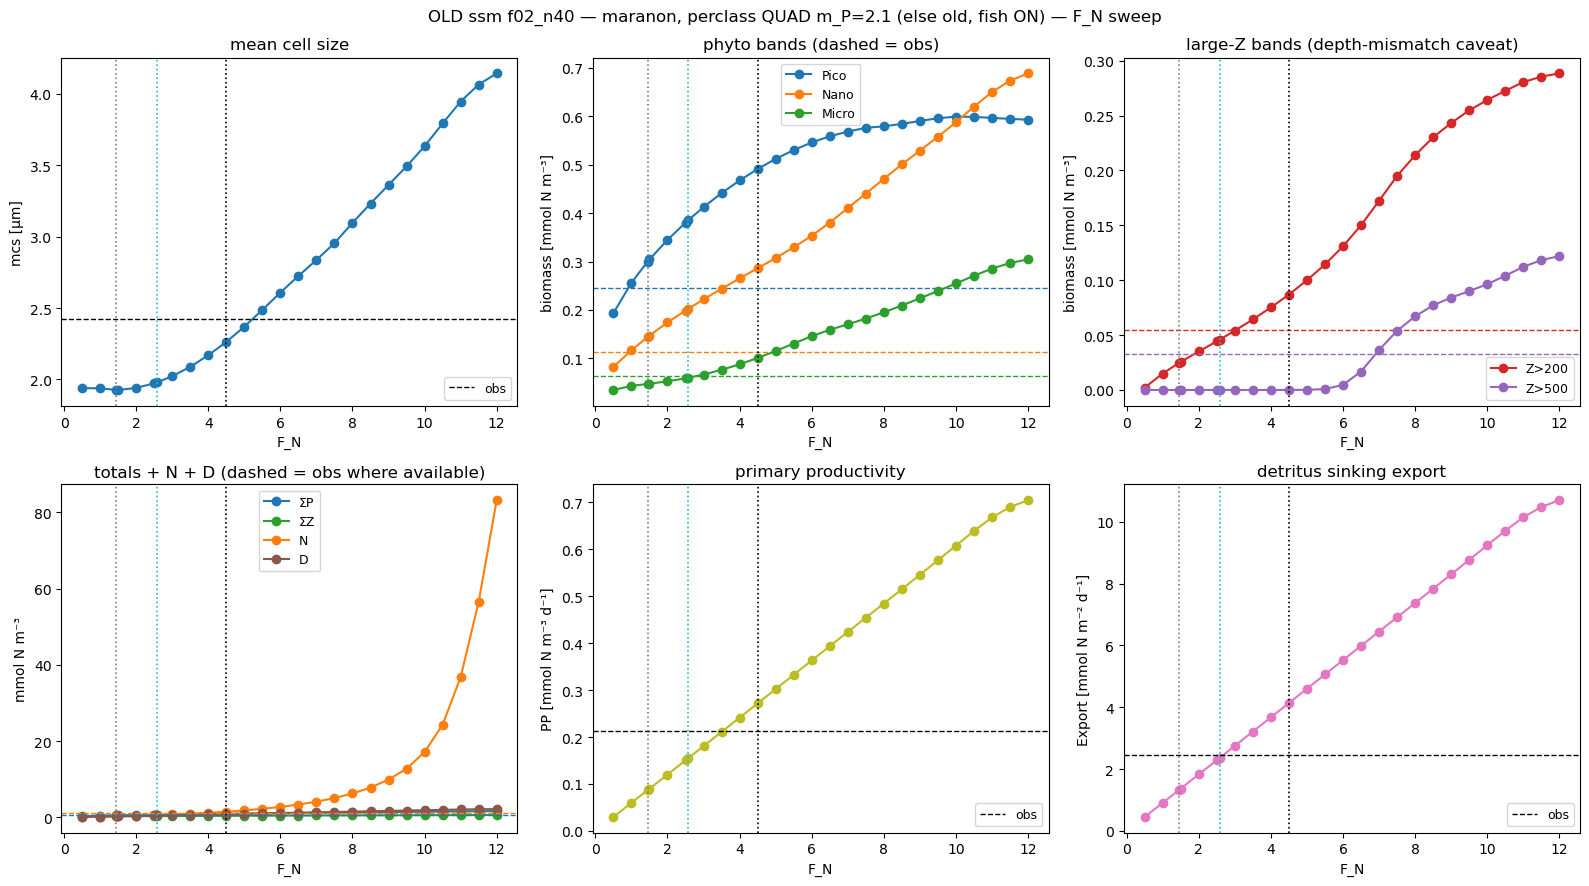

In [16]:
# QUAD PHYTO MORTALITY test — f02_n40. Set FORM, GROWTH, QUAD_RATE; run, repeat.
# Does a density-dependent phyto mortality cap the Pico escape (coherent mcs)?
# One parscan per run.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import cariaco_obs as co
import parscan_utils_extended as pue
import cariaco_ssm_setup as ssm

# ---- KNOBS ---------------------------------------------------------------
FORM      = 'perclass'    # 'perclass' (m·P²) or 'bulk' (m·P·ΣP)
GROWTH    = 'maranon'   # 'maranon' (module default) or 'taniguchi'
QUAD_RATE = 2.1           # quadratic mortality coefficient [(mmolN m-3)^-1 d-1]
# --------------------------------------------------------------------------
MODEL = {'perclass': 'model_phytoquad_pc',          'bulk': 'model_phytoquad_bulk'}[FORM]
SETUP = {'perclass': 'model_setup_slim_phytoquad_pc','bulk': 'model_setup_slim_phytoquad_bulk'}[FORM]
GRID_ESD = ssm.phyto_esd_f02_n40

obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

overrides = {
    'Inflow__de':               50.0,
    'GGE__gge':                 0.17416,
    'GGE__f_egest_D':           0.55602,
    'DetritusRemin__k_remin':   0.07590,
    'PhytoMortality__f_mort_D': 0.47651,
    'Grazing__KsZ':             0.487,
    'PhytoMortality__rate':     QUAD_RATE,    # scalar quadratic coefficient (the magnitude knob)
}
if GROWTH == 'taniguchi':
    overrides['Growth__mu_max']  = 1.36 * GRID_ESD ** (-0.16)
    overrides['Growth__halfsat'] = 0.33 * GRID_ESD ** (0.48)

FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 12.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name=MODEL,
    model_setup_name=SETUP,
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': 50.0})
header = f"OLD ssm f02_n40 — {GROWTH}, {FORM} QUAD m_P={QUAD_RATE} (else old, fish ON) — F_N sweep"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()

In [8]:
GRID_ESD

array([  0.2       ,   0.23875533,   0.28502053,   0.34025086,
         0.40618352,   0.4848924 ,   0.57885322,   0.69102146,
         0.82492528,   0.98477653,   1.17560321,   1.40340766,
         1.67535528,   2.        ,   2.38755328,   2.85020534,
         3.40250856,   4.06183524,   4.84892403,   5.78853225,
         6.91021459,   8.24925277,   9.84776526,  11.75603214,
        14.03407657,  16.7535528 ,  20.        ,  23.87553283,
        28.50205341,  34.0250856 ,  40.61835242,  48.48924034,
        57.88532249,  69.10214589,  82.49252766,  98.47765263,
       117.56032145, 140.34076573, 167.53552801, 200.        ])

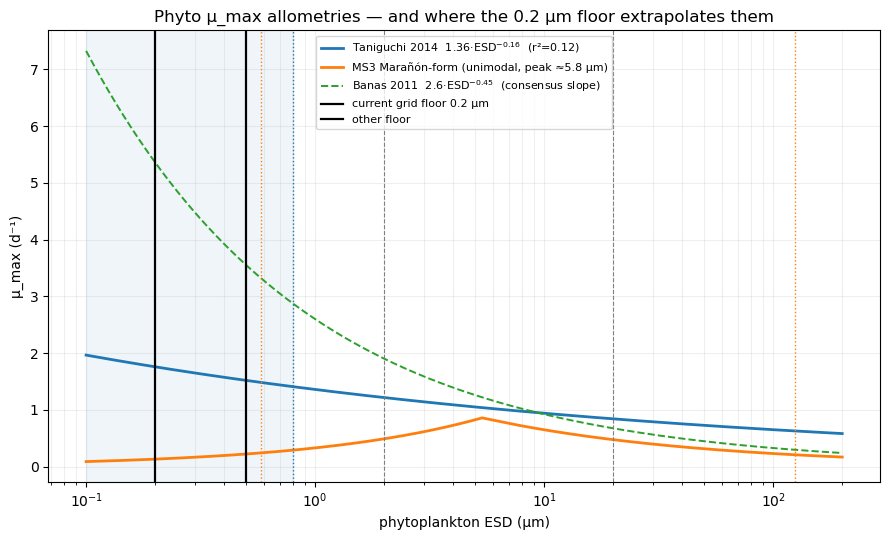

ESD=  0.2 µm:   Taniguchi= 1.76   Marañón= 0.13   Banas= 5.36   d⁻¹
ESD=  0.8 µm:   Taniguchi= 1.41   Marañón= 0.29   Banas= 2.87   d⁻¹
ESD=  2.0 µm:   Taniguchi= 1.22   Marañón= 0.49   Banas= 1.90   d⁻¹
ESD= 5.38 µm:   Taniguchi= 1.04   Marañón= 0.86   Banas= 1.22   d⁻¹


In [18]:
import numpy as np, matplotlib.pyplot as plt

esd = np.logspace(np.log10(0.1), np.log10(200), 400)   # µm

mu_tani  = 1.36 * esd ** (-0.16)                                   # Taniguchi 2014 (r²=0.12, n=101)
mu_mar   = np.where(esd <= 5.38, 0.33 * esd ** 0.57, 1.83 * esd ** (-0.45))  # MS3 Marañón-form
mu_banas = 2.6 * esd ** (-0.45)                                    # Banas 2011 (the −0.45 consensus)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(esd, mu_tani,  lw=2,   color='C0', label='Taniguchi 2014  1.36·ESD$^{-0.16}$  (r²=0.12)')
ax.plot(esd, mu_mar,   lw=2,   color='C1', label='MS3 Marañón-form (unimodal, peak ≈5.8 µm)')
ax.plot(esd, mu_banas, lw=1.4, color='C2', ls='--', label='Banas 2011  2.6·ESD$^{-0.45}$  (consensus slope)')

ax.axvspan(0.1, 0.8, color='C0', alpha=0.07)   # Taniguchi extrapolated below its 0.8 µm floor
ax.axvline(0.8,  color='C0', ls=':', lw=1)     # Taniguchi lower bound
ax.axvline(0.58, color='C1', ls=':', lw=1)     # Marañón data ESD ~0.58 µm
ax.axvline(124,  color='C1', ls=':', lw=1)     # Marañón data ESD ~124 µm
ax.axvline(0.2,  color='k',  lw=1.6, label='current grid floor 0.2 µm')
ax.axvline(0.5,  color='k',  lw=1.6, label='other floor')
for b in (2.0, 20.0):                          # Sieburth Pico | Nano | Micro
    ax.axvline(b, color='grey', ls='--', lw=0.8)

ax.set_xscale('log')   # size axis log (3 decades) — standard for allometries; y linear
ax.set_xlabel('phytoplankton ESD (µm)'); ax.set_ylabel('μ_max (d⁻¹)')
ax.set_title('Phyto μ_max allometries — and where the 0.2 µm floor extrapolates them')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)
plt.tight_layout(); plt.show()

mar = lambda s: 0.33*s**0.57 if s <= 5.38 else 1.83*s**-0.45
for s in (0.2, 0.8, 2.0, 5.38):
    print(f"ESD={s:>5} µm:   Taniguchi={1.36*s**-0.16:5.2f}   Marañón={mar(s):5.2f}   Banas={2.6*s**-0.45:5.2f}   d⁻¹")

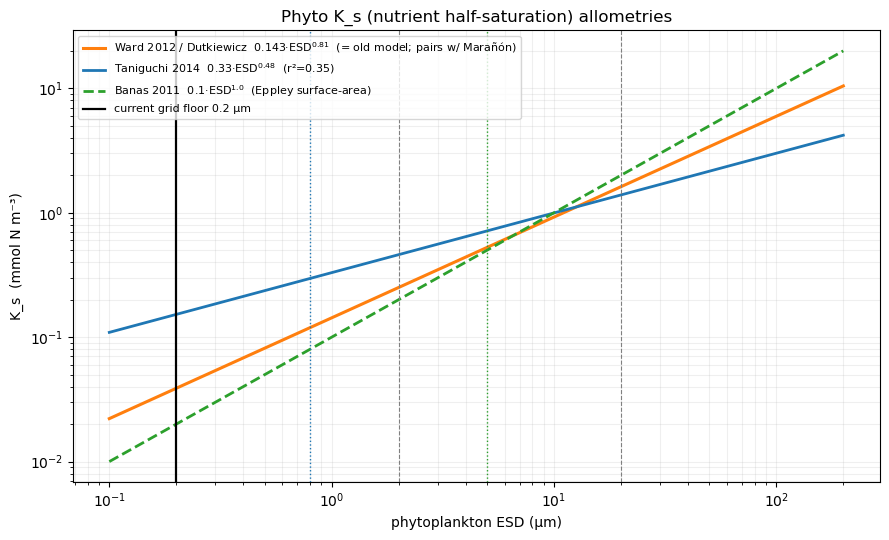

ESD=   0.2 µm:   Taniguchi= 0.152   Ward/Dutk= 0.039   Banas= 0.020   mmol N m⁻³
ESD=   0.8 µm:   Taniguchi= 0.296   Ward/Dutk= 0.119   Banas= 0.080   mmol N m⁻³
ESD=   2.0 µm:   Taniguchi= 0.460   Ward/Dutk= 0.251   Banas= 0.200   mmol N m⁻³
ESD=  20.0 µm:   Taniguchi= 1.390   Ward/Dutk= 1.619   Banas= 2.000   mmol N m⁻³
ESD= 200.0 µm:   Taniguchi= 4.198   Ward/Dutk=10.451   Banas=20.000   mmol N m⁻³


In [19]:
import numpy as np, matplotlib.pyplot as plt

esd = np.logspace(np.log10(0.1), np.log10(200), 400)   # µm

# K_s (Monod nutrient half-saturation), ESD-native [mmol N m⁻³ = µM N]
ks_tani  = 0.33  * esd ** 0.48     # Taniguchi 2014 (r²=0.35, n=31)
ks_ward  = 0.143 * esd ** 0.81     # Ward 2012 / Dutkiewicz (= old model 0.144; = old "Marañón×Aksnes")
ks_banas = 0.10  * esd ** 1.0      # Banas 2011 / Eppley 1969 (surface-area)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(esd, ks_ward,  lw=2.2, color='C1',
        label='Ward 2012 / Dutkiewicz  0.143·ESD$^{0.81}$  (= old model; pairs w/ Marañón)')
ax.plot(esd, ks_tani,  lw=2,   color='C0',
        label='Taniguchi 2014  0.33·ESD$^{0.48}$  (r²=0.35)')
ax.plot(esd, ks_banas, lw=2,   color='C2', ls='--',
        label='Banas 2011  0.1·ESD$^{1.0}$  (Eppley surface-area)')

ax.axvline(0.2, color='k',  lw=1.6, label='current grid floor 0.2 µm')
ax.axvline(5.0, color='C2', ls=':', lw=1)   # Banas K_s validated 5–210 µm → extrapolated below
ax.axvline(0.8, color='C0', ls=':', lw=1)   # Taniguchi lower bound 0.8 µm
for b in (2.0, 20.0):                        # Sieburth Pico | Nano | Micro
    ax.axvline(b, color='grey', ls='--', lw=0.8)

ax.set_xscale('log'); ax.set_yscale('log')   # log-log: K_s spans ~3 decades
ax.set_xlabel('phytoplankton ESD (µm)'); ax.set_ylabel('K_s  (mmol N m⁻³)')
ax.set_title('Phyto K_s (nutrient half-saturation) allometries')
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, which='both', alpha=0.2)
plt.tight_layout(); plt.show()

for s in (0.2, 0.8, 2.0, 20.0, 200.0):
    print(f"ESD={s:>6} µm:   Taniguchi={0.33*s**0.48:6.3f}   Ward/Dutk={0.143*s**0.81:6.3f}   Banas={0.1*s**1.0:6.3f}   mmol N m⁻³")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_baseline_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 26 points using 8 workers...
1D Scan complete. Time taken: 18.80672 seconds.

=== baseline_r0 (Banas m_P=0.1·μ, fish off) — maranon_ward — F_N sweep @ upwelling d_e/T ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   1.26   0.159   0.068   0.000   0.227  0.0000  0.0000   0.061   0.073   0.098   0.026   0.492
 1.000   1.47   0.214   0.124   0.000   0.339  0.0000  0.0000   0.110   0.151   0.195   0.052   0.974
 1.450   1.92   0.258   0.124   0.040   0.422  0.0030  0.0000   0.148   0.235   0.281   0.076   1.403
 1.500   1.88   0.262   0.127   0.038   0.427  0.0027  0.0000   0.153   0.246   0.290   0.079   1.450
 2.000  

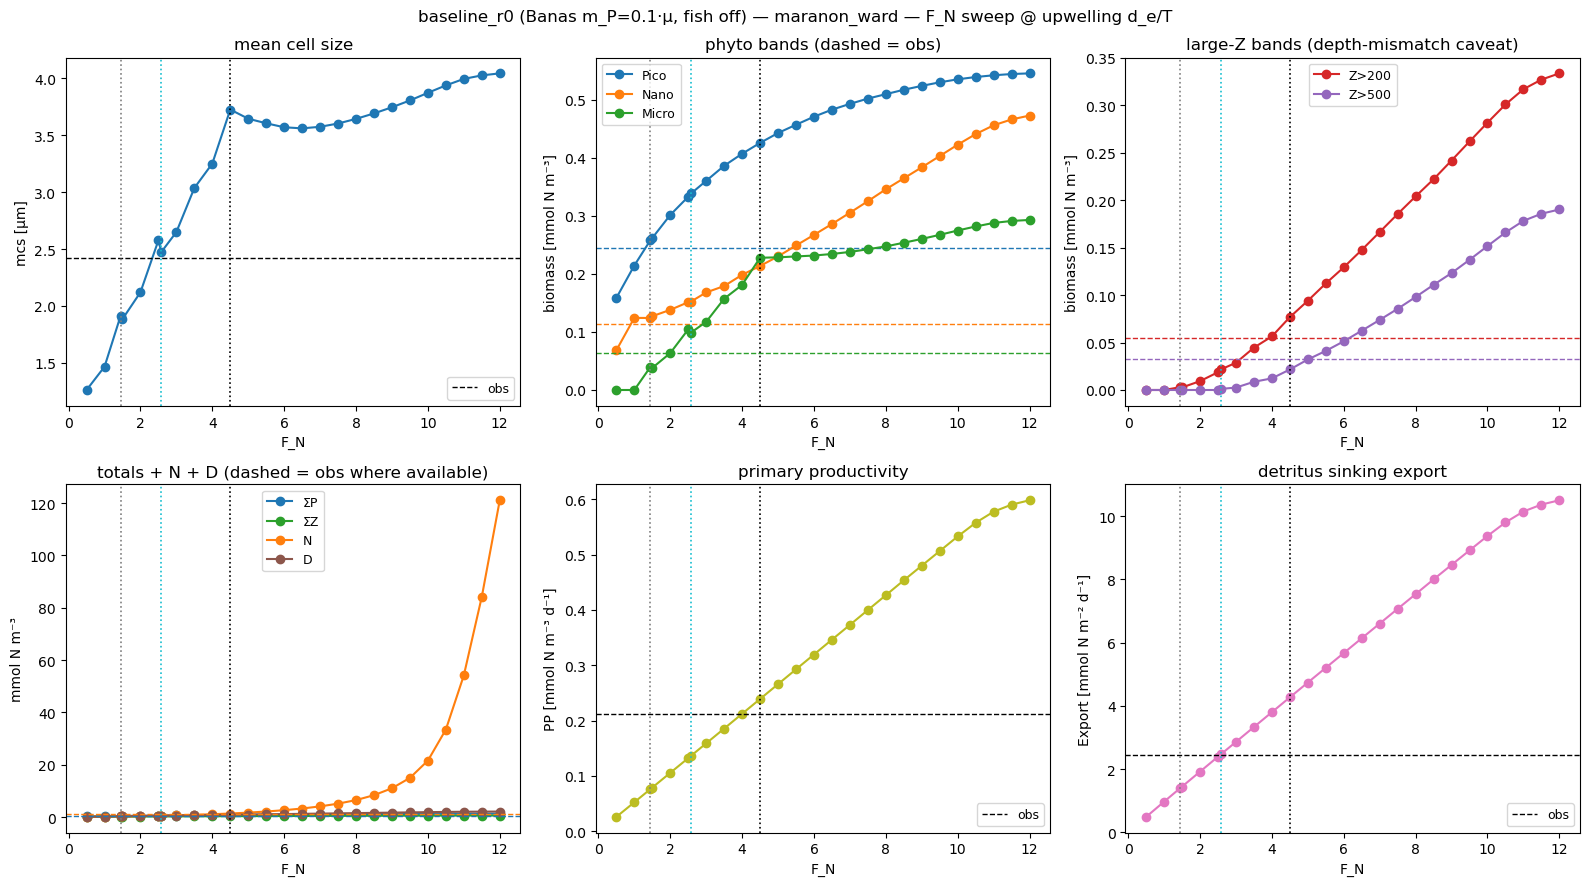

In [23]:
# ALLOMETRY-COMBO F_N sweep — baseline_r0, Banas linear mortality (coeff=0.1).
# Growth μ_max + K_s via overrides; else baseline (omnivory, Dutkiewicz grazing,
# Cloern T, fish r_F=0). d_e + T fixed at upwelling, sweep F_N. One parscan per run.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import baseline_r0_setups as brs
import cariaco_obs as co
import parscan_utils_extended as pue

esd = brs.phyto_esd   # 40-class, 0.2 µm grid

# ---- KNOB ----------------------------------------------------------------
COMBO = 'maranon_ward'   # 'maranon_ward' | 'banas_banas' | 'taniguchi'
# --------------------------------------------------------------------------
ALLOM = {
    'maranon_ward': (np.where(esd <= 5.38, 0.33*esd**0.57, 1.83*esd**-0.45),  # Marañón μ
                     0.143 * esd ** 0.81),                                     # Ward K_s
    'banas_banas':  (2.6 * esd ** -0.45,                                       # Banas μ
                     0.10 * esd ** 1.0),                                       # Banas K_s
    'taniguchi':    (1.36 * esd ** -0.16,                                      # Taniguchi μ
                     0.33 * esd ** 0.48),                                      # Taniguchi K_s
}
mu_arr, ks_arr = ALLOM[COMBO]

obs_vec, labels, bin_defs, monthly_df, _ = co.load_cariaco_targets(
    regime='all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)
*_, forcing_up = co.load_cariaco_targets(
    regime='upwelling', months='hplc', agg='median', include_temperature=True)

# fix everything from the upwelling forcing EXCEPT F_N (the scan axis); add allometries
overrides = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
overrides['Growth__mu_max']  = mu_arr     # broadcast μ_max — Banas mortality (0.1·μ) should track this
overrides['Growth__halfsat'] = ks_arr

FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 12.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': overrides['Inflow__de']})
header = f"baseline_r0 (Banas m_P=0.1·μ, fish off) — {COMBO} — F_N sweep @ upwelling d_e/T"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_baseline_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 24 points using 8 workers...
1D Scan complete. Time taken: 23.60563 seconds.


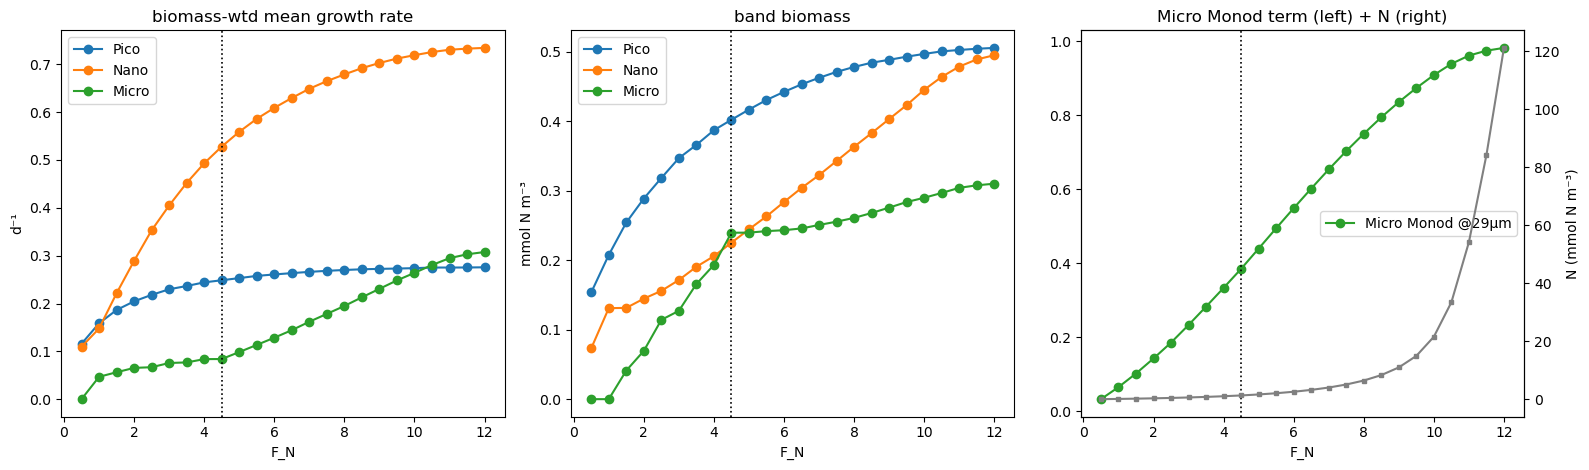

In [24]:
# DIAGNOSTIC A — per-band realized growth rate vs F_N (Marañón+Ward+Banas, baseline_r0).
# Discriminator for the F_N≈4.5 kink: is Micro growth-saturated there (growth-side),
# or still rising while its biomass flatlines (top-down)?  Uses N + allometry only.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import baseline_r0_setups as brs
import cariaco_obs as co

esd    = brs.phyto_esd
mu_arr = np.where(esd <= 5.38, 0.33*esd**0.57, 1.83*esd**-0.45)   # Marañón μ
ks_arr = 0.143 * esd ** 0.81                                       # Ward K_s

*_, forcing_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median',
                                         include_temperature=True)
f_T = brs.Q10_GROW ** ((forcing_up['Temperature__value'] - brs.T_REF) / 10.0)   # growth Q10 factor
overrides = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
overrides['Growth__mu_max']  = mu_arr
overrides['Growth__halfsat'] = ks_arr

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim', param_name='Inflow__FN',
    param_values=np.linspace(0.5, 12.0, 24), fixed_overrides=overrides,
    postprocess_name='avg_tail', postprocess_kwargs={'avg_window': 1000}, processes=8)

Pda = scan['Phytoplankton__biomass'].squeeze('time'); Nda = scan['Nutrient__value'].squeeze('time')
fn  = Pda['Inflow__FN'].values; order = np.argsort(fn); fn = fn[order]
P   = Pda.transpose('Inflow__FN', 'phyto').values[order]            # (nFN, nclass)
N   = Nda.transpose('Inflow__FN').values[order]                    # (nFN,)

g = f_T * mu_arr[None, :] * (N[:, None] / (N[:, None] + ks_arr[None, :]))   # realized growth rate
bands = {'Pico': esd < 2.0, 'Nano': (esd >= 2.0) & (esd < 20.0), 'Micro': esd >= 20.0}
col   = {'Pico': 'C0', 'Nano': 'C1', 'Micro': 'C2'}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
for b, mask in bands.items():
    Pb   = P[:, mask].sum(1)
    gbar = (g[:, mask] * P[:, mask]).sum(1) / np.maximum(Pb, 1e-30)
    ax[0].plot(fn, gbar, '-o', color=col[b], label=b)
    ax[1].plot(fn, Pb,   '-o', color=col[b], label=b)
i30 = np.argmin(np.abs(esd - 30.0))
ax[2].plot(fn, N/(N + ks_arr[i30]), '-o', color='C2', label=f'Micro Monod @{esd[i30]:.0f}µm')
axN = ax[2].twinx(); axN.plot(fn, N, '-s', color='grey', ms=3); axN.set_ylabel('N (mmol N m⁻³)')
for a in ax: a.axvline(4.5, color='k', ls=':', lw=1.2); a.set_xlabel('F_N')
ax[0].set_title('biomass-wtd mean growth rate'); ax[0].set_ylabel('d⁻¹'); ax[0].legend()
ax[1].set_title('band biomass'); ax[1].set_ylabel('mmol N m⁻³'); ax[1].legend()
ax[2].set_title('Micro Monod term (left) + N (right)'); ax[2].legend(loc='center right')
plt.tight_layout(); plt.show()

PROGRESS: Completed 20/20 outer points. (Inflow__FN = 12.0).

2D Scan complete. Total Time taken: 63.91659 seconds.


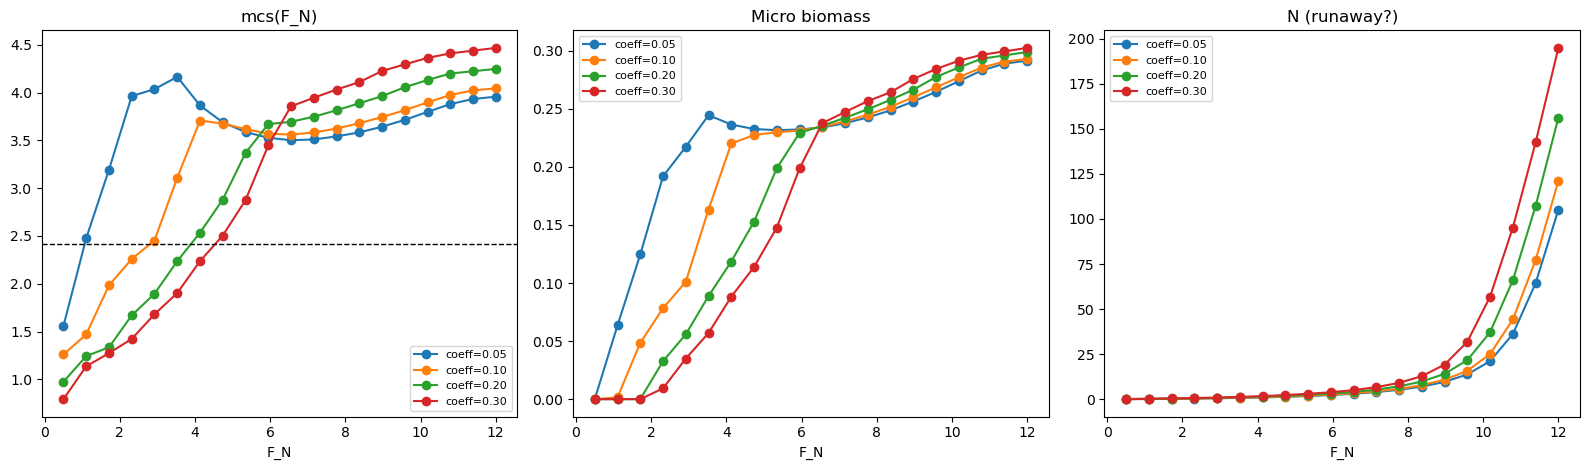

In [25]:
# MORTALITY SENSITIVITY — Banas coeff × F_N (Marañón+Ward, baseline_r0).
# How mortality magnitude reshapes mcs(F_N), Micro, and the runaway.
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import baseline_r0_setups as brs
import cariaco_obs as co
import parscan_utils_extended as pue

esd = brs.phyto_esd
mu_arr = np.where(esd <= 5.38, 0.33*esd**0.57, 1.83*esd**-0.45)
ks_arr = 0.143 * esd ** 0.81

obs_vec, labels, bin_defs, monthly_df, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)
*_, forcing_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
overrides = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
overrides['Growth__mu_max']  = mu_arr
overrides['Growth__halfsat'] = ks_arr

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim',
    param_name='Inflow__FN',            param_values=np.linspace(0.5, 12.0, 20),
    param_name2='PhytoMortality__coeff', param_values2=np.array([0.05, 0.10, 0.20, 0.30]),
    fixed_overrides=overrides,
    postprocess_name='avg_tail', postprocess_kwargs={'avg_window': 1000}, processes=8)

m = pue.extract_scan_metrics_2d(scan, 'Inflow__FN', 'PhytoMortality__coeff',
                                {'Inflow__de': overrides['Inflow__de']})
fn = m['axis_1']; coeffs = m['axis_2']
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
for j, c in enumerate(coeffs):
    ax[0].plot(fn, m['mcs'][:, j],     '-o', label=f'coeff={c:.2f}')
    ax[1].plot(fn, m['P_micro'][:, j], '-o', label=f'coeff={c:.2f}')
    ax[2].plot(fn, m['N'][:, j],       '-o', label=f'coeff={c:.2f}')
ax[0].axhline(obs_refs['mcs'], color='k', ls='--', lw=1)
ax[0].set_title('mcs(F_N)'); ax[1].set_title('Micro biomass'); ax[2].set_title('N (runaway?)')
for a in ax: a.set_xlabel('F_N'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_baseline_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 26 points using 8 workers...
1D Scan complete. Time taken: 183.92347 seconds.

=== baseline_r0 — Banas μ + K_s + I_max (σ=0.25), Type III — F_N sweep @ upwelling ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   0.63   0.026   0.000   0.000   0.026  0.0000  0.0000   0.038   0.004   0.099   0.025   0.497
 1.000   0.63   0.042   0.000   0.000   0.042  0.0000  0.0000   0.058   0.005   0.199   0.052   0.993
 1.450   0.63   0.063   0.000   0.000   0.063  0.0000  0.0000   0.074   0.006   0.288   0.076   1.438
 1.500   0.63   0.070   0.000   0.000   0.070  0.0000  0.0000   0.074   0.006   0.298   0.078   1.488
 2.000   0.63

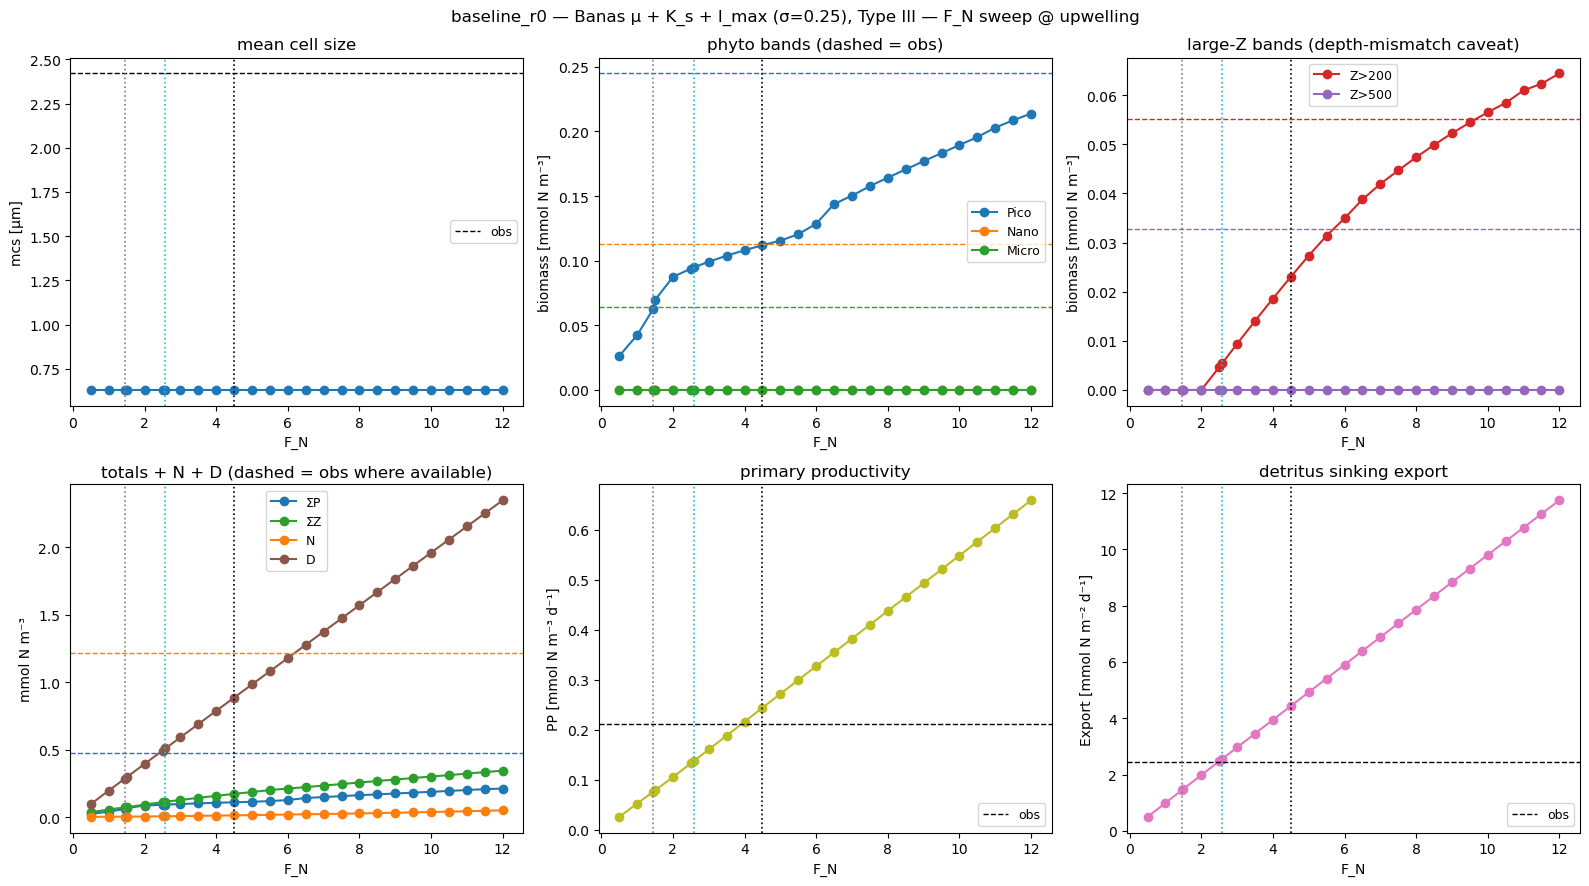

In [26]:
# BANAS μ + Banas K_s + Banas I_max (26·s^-0.40) + σ=0.25, in the Type III model.
# Else baseline_r0 (K_sZ=0.23 + Type III refuge kept, GGE 0.25, Banas mort 0.1, fish off).
# Q: does Banas's stronger small-grazer I_max break the Pico-monoculture collapse?
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import baseline_r0_setups as brs
import cariaco_obs as co
import parscan_utils_extended as pue

esd, zoo_esd = brs.phyto_esd, brs.zoo_esd
mu_banas   = 2.6  * esd ** -0.45        # Banas μ
ks_banas   = 0.1  * esd ** 1.0          # Banas K_s
imax_banas = 26.0 * zoo_esd ** -0.40    # Banas I_max (predator ESD)

obs_vec, labels, bin_defs, monthly_df, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)
*_, forcing_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)

overrides = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
overrides.update({
    'Growth__mu_max':     mu_banas,
    'Growth__halfsat':    ks_banas,
    'Grazing__Imax':      imax_banas,    # Banas grazing allometry (still Type III)
    'Grazing__sigma_log': 0.25,          # Banas kernel width
})
FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 12.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim', param_name='Inflow__FN',
    param_values=FN_VALUES, fixed_overrides=overrides,
    postprocess_name='avg_tail', postprocess_kwargs={'avg_window': 1000}, processes=8)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': overrides['Inflow__de']})
header = "baseline_r0 — Banas μ + K_s + I_max (σ=0.25), Type III — F_N sweep @ upwelling"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_typeII_banas' and setup 'setup_baseline_typeII_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 26 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4386 on P[0] = -3.25e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2040 on P[0] = -8.08e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3845 on P[0] = -2.16e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={

1D Scan complete. Time taken: 34.62442 seconds.

=== baseline_r0 TYPE II (Banas I_max, K_sZ=3, σ=0.25) — taniguchi growth — F_N @ upwelling ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   0.63   0.094   0.000   0.000   0.094  0.0000  0.0000   0.049   0.041   0.099   0.025   0.495
 1.000   0.66   0.124   0.003   0.000   0.126  0.0000  0.0000   0.103   0.062   0.195   0.051   0.977
 1.450   0.64   0.151   0.001   0.000   0.152  0.0000  0.0000   0.135   0.074   0.282   0.075   1.411
 1.500   0.85   0.152   0.023   0.000   0.175  0.0000  0.0000   0.133   0.072   0.292   0.078   1.462
 2.000   1.18   0.174   0.065   0.000   0.239  0.0000  0.0000   0.155   0.077   0.389   0.104   1.947
 2.500   1.18   0.209   0.078   0.000   0.287  0.0000  0.0000   0.178   0.082   0.486   0.130   2.432
 2.580   1.17   0.213   0.079   0.000   0.292  0.0000  0.0000   0.182   0.083   0.502   0.135   2.509
 3.000   1.05   0.236   0.068   0.000   

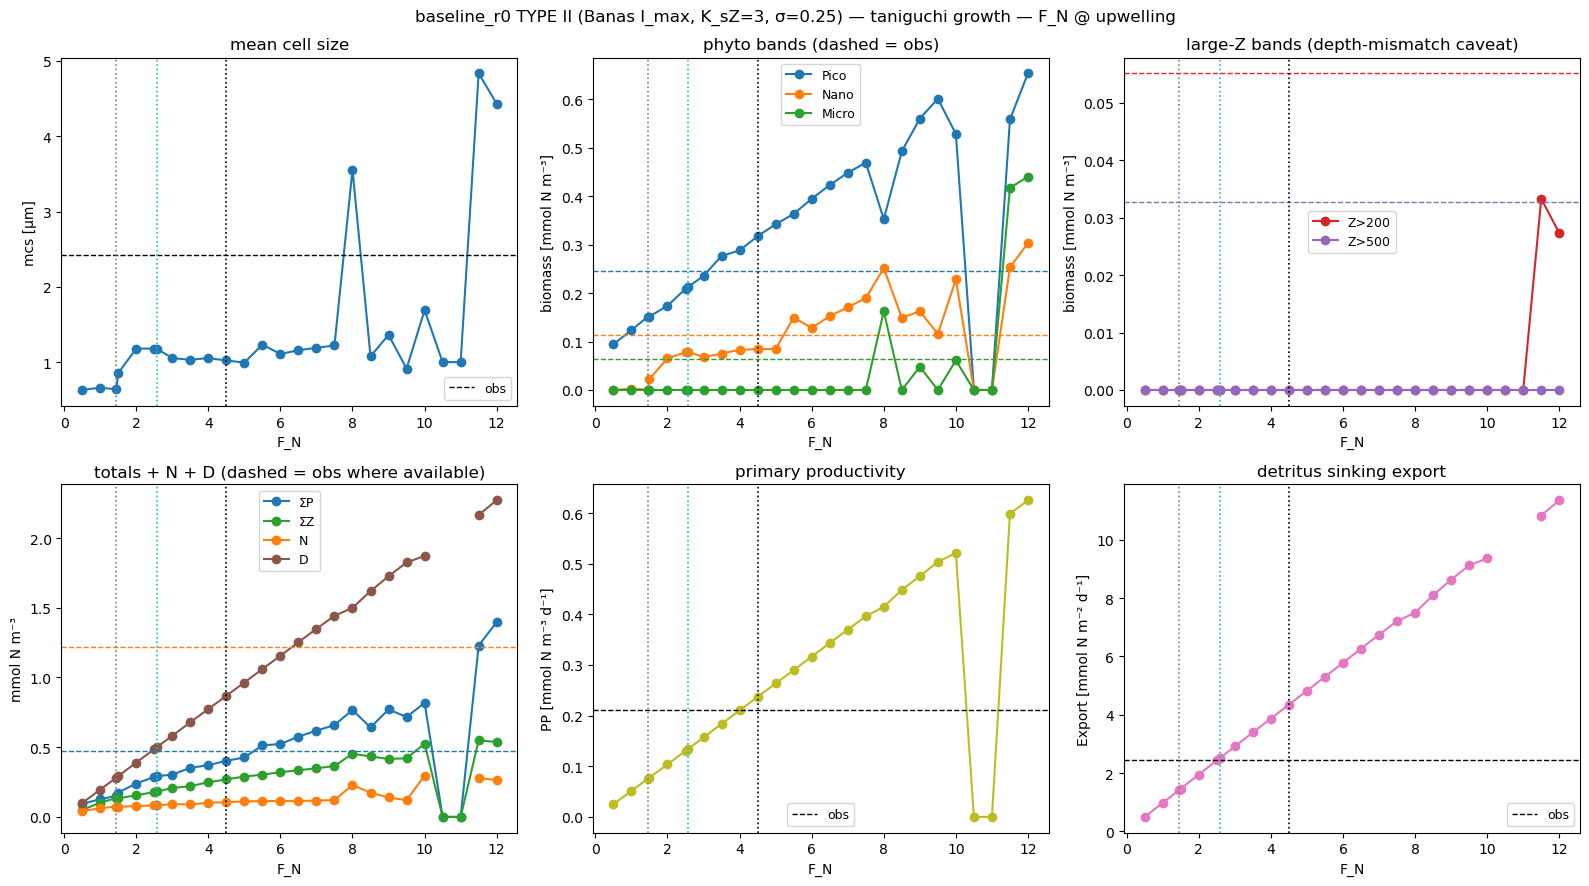

In [6]:
# TYPE II GRAZING test (Banas Eq.8, no refuge) — growth allometry knobbed.
# Grazing held at Banas Type II (I_max 26·s^-0.40, K_sZ=3, σ=0.25), Banas mort 0.1, fish off.
# Q: does the refuge-free response break the Pico-monoculture collapse?
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan, avg_tail
import baseline_r0_setups as brs
import cariaco_obs as co
import parscan_utils_extended as pue

esd, zoo_esd = brs.phyto_esd, brs.zoo_esd

# ---- KNOB ----------------------------------------------------------------
COMBO = 'taniguchi'   # 'banas' | 'maranon_ward' | 'taniguchi'
# --------------------------------------------------------------------------
ALLOM = {
    'banas':        (2.6 * esd ** -0.45,                                      0.1   * esd ** 1.0),
    'maranon_ward': (np.where(esd <= 5.38, 0.33*esd**0.57, 1.83*esd**-0.45),  0.143 * esd ** 0.81),
    'taniguchi':    (1.36 * esd ** -0.16,                                     0.33  * esd ** 0.48),
}
mu_arr, ks_arr = ALLOM[COMBO]
imax_banas = 26.0 * zoo_esd ** -0.40

obs_vec, labels, bin_defs, monthly_df, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)
*_, forcing_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
overrides = {k: v for k, v in forcing_up.items() if k != 'Inflow__FN'}
overrides.update({
    'Growth__mu_max':     mu_arr,
    'Growth__halfsat':    ks_arr,
    'Grazing__Imax':      imax_banas,   # Banas I_max
    'Grazing__KsZ':       3.0,          # Banas Type II half-sat (NOT the Type III 0.23)
    'Grazing__sigma_log': 0.25,         # Banas kernel width
})
FN_VALUES = np.unique(np.concatenate([np.linspace(0.5, 12.0, 24), [1.45, 2.58, 4.5]]))

scan = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline_typeII_banas',
    model_setup_name='setup_baseline_typeII_banas_slim', param_name='Inflow__FN',
    param_values=FN_VALUES, fixed_overrides=overrides,
    postprocess_name='avg_tail', postprocess_kwargs={'avg_window': 1000}, processes=8)
metrics = pue.extract_scan_metrics_1d(scan, 'Inflow__FN', {'Inflow__de': overrides['Inflow__de']})
header = f"baseline_r0 TYPE II (Banas I_max, K_sZ=3, σ=0.25) — {COMBO} growth — F_N @ upwelling"
pue.print_scan_table_1d(metrics, obs_refs, header, axis_label='F_N')
fig = pue.plot_scan_panels_1d(metrics, obs_refs, header, axis_label='F_N')
for ax in fig.axes:
    for fn, c in [(1.45, 'C7'), (2.58, 'C9'), (4.5, 'k')]:
        ax.axvline(fn, color=c, ls=':', lw=1.2)
plt.show()